Saving marketing_campaign.xlsx to marketing_campaign (1).xlsx
Dataset Loaded Successfully

Dataset Shape:
(2240, 29)

First 5 Records:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04       58       635  ...                  7             0   
1  2014-03-08       38        11  ...                  5             0   
2  2013-08-21       26       426  ...                  4             0   
3  2014-02-10       26        11  ...                  6             0   
4  2014-01-19       94    

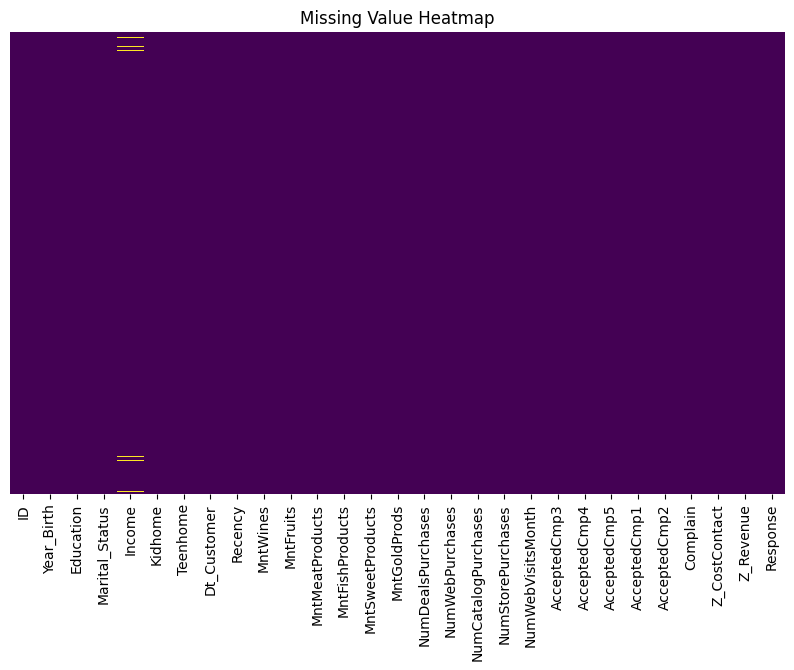


Missing Values Before Treatment:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

Missing Values After Treatment:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome        

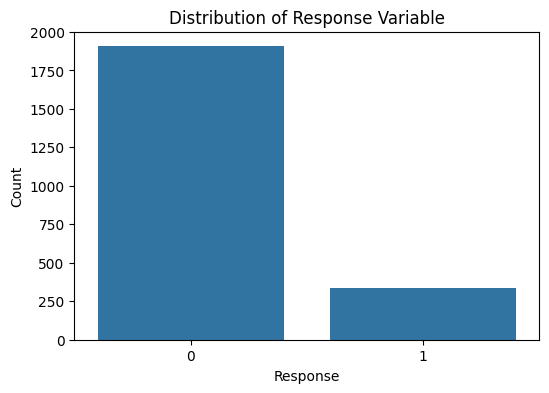

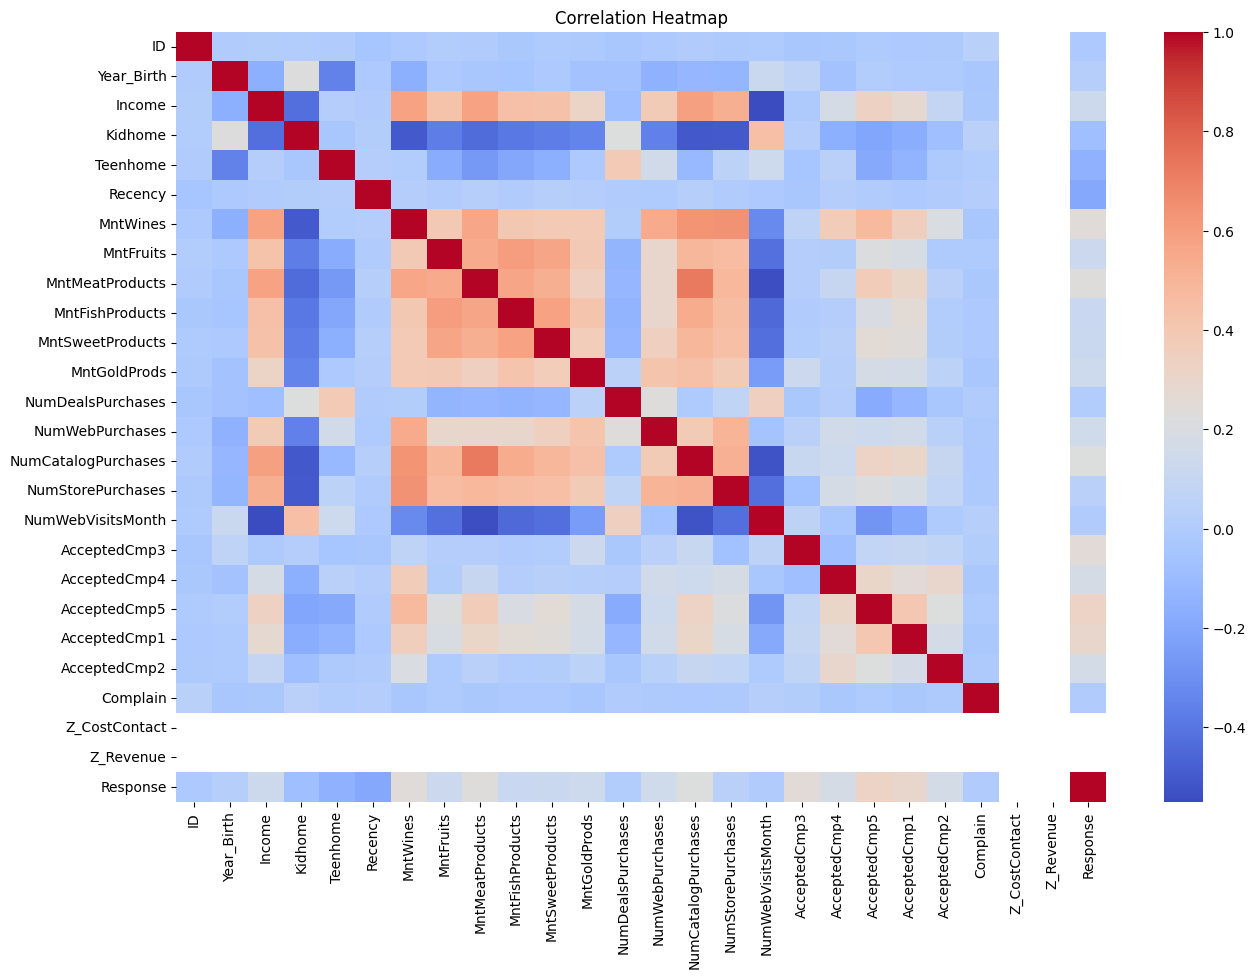


Feature Engineering Completed

New Features Created:
   Customer_Tenure  Age  Total_Children  Total_Spending  Total_Purchases
0              663   69               0            1617               22
1              113   72               2              27                4
2              312   61               0             776               20
3              139   42               1              53                6
4              161   45               1             422               14

Columns Removed Successfully

Categorical Variables Encoded

Feature Matrix Shape: (2237, 29)
Target Variable Shape: (2237,)

Training Data Shape: (1789, 29)
Testing Data Shape: (448, 29)

Feature Scaling Completed
Scaled Training Shape: (1789, 29)
Scaled Testing Shape: (448, 29)


In [ ]:
# ==========================================================
# STEP 1: IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files


# ==========================================================
# STEP 2: UPLOAD DATASET
# ==========================================================

uploaded = files.upload()

# Automatically read uploaded Excel file

file_name = list(uploaded.keys())[0]

df = pd.read_excel('/content/marketing_campaign.xlsx')


# ==========================================================
# STEP 3: DISPLAY BASIC INFORMATION
# ==========================================================

print("Dataset Loaded Successfully")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Records:")
print(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())


# ==========================================================
# STEP 4: CHECK MISSING VALUES
# ==========================================================

print("\nMissing Values:")
print(df.isnull().sum())

# Missing Value Visualization

plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='viridis'
)

plt.title(
    "Missing Value Heatmap"
)

plt.show()


# ==========================================================
# STEP 5: HANDLE MISSING VALUES
# ==========================================================

print("\nMissing Values Before Treatment:")

print(df.isnull().sum())

# Income has missing values
# Median Imputation is preferred because Income may contain outliers

df["Income"] = df["Income"].fillna(
    df["Income"].median()
)

print("\nMissing Values After Treatment:")

print(df.isnull().sum())

# ==========================================================
# STEP 6: CHECK DUPLICATE RECORDS
# ==========================================================

duplicates = df.duplicated().sum()

print("\nNumber of Duplicate Records:", duplicates)

# Remove duplicates if any exist

df = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:")

print(df.shape)


# ==========================================================
# STEP 7: TARGET VARIABLE DISTRIBUTION
# ==========================================================

print("\nResponse Variable Distribution:")

print(df["Response"].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(
    x="Response",
    data=df
)

plt.title(
    "Distribution of Response Variable"
)

plt.xlabel(
    "Response"
)

plt.ylabel(
    "Count"
)

plt.show()


# ==========================================================
# STEP 8: CORRELATION ANALYSIS
# ==========================================================

plt.figure(figsize=(15,10))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    annot=False
)

plt.title(
    "Correlation Heatmap"
)

plt.show()


# ==========================================================
# STEP 9: FEATURE ENGINEERING
# ==========================================================

# Convert Dt_Customer to Date Format

df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"]
)

# Create Customer Tenure

latest_date = df["Dt_Customer"].max()

df["Customer_Tenure"] = (
    latest_date - df["Dt_Customer"]
).dt.days

# Create Customer Age

df["Age"] = 2026 - df["Year_Birth"]

# Remove Customers Above 100 Years

df = df[
    df["Age"] <= 100
]

# Create Total Children

df["Total_Children"] = (
    df["Kidhome"] +
    df["Teenhome"]
)

# Create Total Spending

df["Total_Spending"] = (

    df["MntWines"]

    + df["MntFruits"]

    + df["MntMeatProducts"]

    + df["MntFishProducts"]

    + df["MntSweetProducts"]

    + df["MntGoldProds"]

)

# Create Total Purchases

df["Total_Purchases"] = (

    df["NumWebPurchases"]

    + df["NumCatalogPurchases"]

    + df["NumStorePurchases"]

)

print("\nFeature Engineering Completed")


# ==========================================================
# STEP 10: VIEW NEW FEATURES
# ==========================================================

new_features = [

    "Customer_Tenure",

    "Age",

    "Total_Children",

    "Total_Spending",

    "Total_Purchases"

]

print("\nNew Features Created:")

print(
    df[new_features].head()
)
# ==========================================================
# STEP 11: DROP IRRELEVANT COLUMNS
# ==========================================================

df.drop(

    columns=[

        "ID",

        "Dt_Customer",

        "Z_CostContact",

        "Z_Revenue"

    ],

    inplace=True

)

print("\nColumns Removed Successfully")


# ==========================================================
# STEP 12: ENCODE CATEGORICAL VARIABLES
# ==========================================================

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Education"] = le.fit_transform(
    df["Education"]
)

df["Marital_Status"] = le.fit_transform(
    df["Marital_Status"]
)

print("\nCategorical Variables Encoded")


# ==========================================================
# STEP 13: DEFINE FEATURES AND TARGET
# ==========================================================

X = df.drop(

    "Response",

    axis=1

)

y = df["Response"]

print("\nFeature Matrix Shape:", X.shape)

print("Target Variable Shape:", y.shape)


# ==========================================================
# STEP 14: TRAIN TEST SPLIT
# 80:20 SPLIT
# ==========================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("\nTraining Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)


# ==========================================================
# STEP 15: FEATURE SCALING
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("\nFeature Scaling Completed")

print(
    "Scaled Training Shape:",
    X_train_scaled.shape
)

print(
    "Scaled Testing Shape:",
    X_test_scaled.shape
)



Epoch = 50 | F1 Score = 0.5487
Epoch = 100 | F1 Score = 0.5042
Epoch = 150 | F1 Score = 0.5424
Epoch = 200 | F1 Score = 0.5546
Epoch = 250 | F1 Score = 0.5484
Epoch = 300 | F1 Score = 0.5088
Epoch = 350 | F1 Score = 0.5410
Epoch = 400 | F1 Score = 0.5172
Epoch = 450 | F1 Score = 0.5378
Epoch = 500 | F1 Score = 0.5289
Epoch = 600 | F1 Score = 0.5289
Epoch = 700 | F1 Score = 0.5041
Epoch = 800 | F1 Score = 0.5254
Epoch = 900 | F1 Score = 0.5556
Epoch = 1000 | F1 Score = 0.5217
Epoch = 1200 | F1 Score = 0.5217
Epoch = 1400 | F1 Score = 0.5410
Epoch = 1600 | F1 Score = 0.5041
Epoch = 1800 | F1 Score = 0.4874
Epoch = 2000 | F1 Score = 0.5246

Best Epoch = 900
Maximum F1 Score = 0.5556


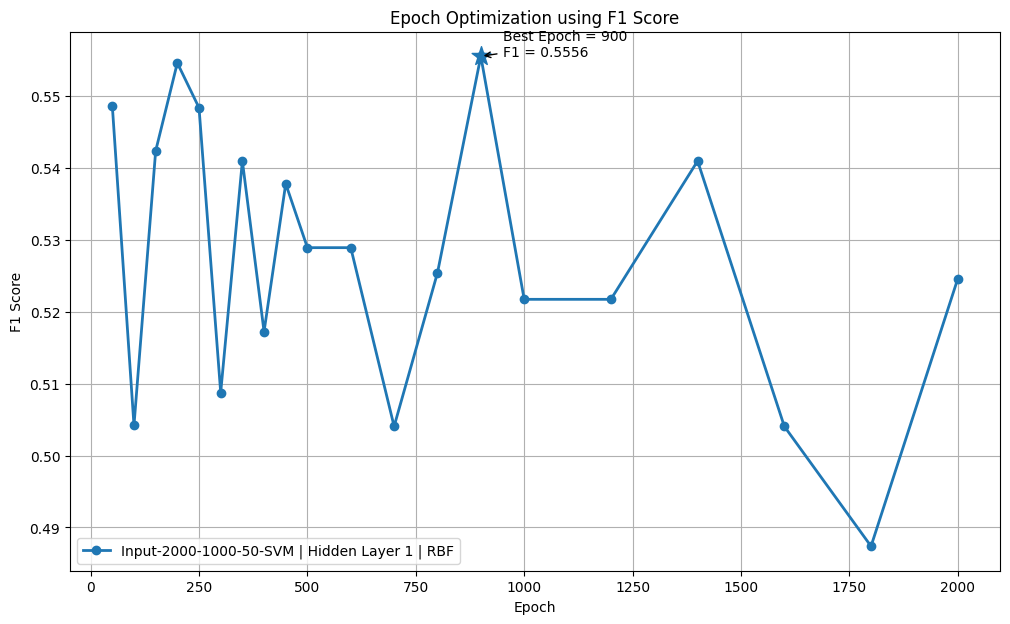

In [ ]:
# ==========================================================
# EPOCH OPTIMIZATION GRAPH
# Architecture: Input-2000-1000-50-SVM
# Hidden Layer for Classification: 3 (50 Neurons)
# Kernel: RBF
# ==========================================================

from tensorflow.keras.models import Model
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

from sklearn.svm import SVC
from sklearn.metrics import f1_score

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# EPOCH SEARCH SPACE
# ==========================================================

epoch_list = [

    50,100,150,200,250,300,350,400,450,500,

    600,700,800,900,1000,1200,1400,1600,

    1800,2000

]

f1_scores = []

# ==========================================================
# TRAIN ANN + RBF SVM FOR EACH EPOCH
# ==========================================================

for epoch_value in epoch_list:

    ann = Sequential([

        Input(
            shape=(X_train_scaled.shape[1],)
        ),

        Dense(
            2000,
            activation='relu'

        ),

        Dense(
            1000,
            activation='relu'
        ),

        Dense(
            50,
            activation='relu',
            name='feature_layer'
        ),

        Dense(
            1,
            activation='sigmoid'
        )

    ])

    ann.compile(

        optimizer=SGD(
            learning_rate=0.01
        ),

        loss='binary_crossentropy',

        metrics=['accuracy']

    )

    ann.fit(

        X_train_scaled,

        y_train,

        epochs=epoch_value,

        batch_size=32,

        verbose=0

    )

    feature_model = Model(

        inputs=ann.inputs,

        outputs=ann.get_layer(
            "feature_layer"
        ).output

    )

    X_train_features = feature_model.predict(

        X_train_scaled,

        verbose=0

    )

    X_test_features = feature_model.predict(

        X_test_scaled,

        verbose=0

    )

    svm_model = SVC(

        kernel='rbf',

        C=1,

        gamma='scale',

        probability=True,

        random_state=42

    )

    svm_model.fit(

        X_train_features,

        y_train

    )

    y_pred = svm_model.predict(

        X_test_features

    )

    f1 = f1_score(

        y_test,

        y_pred,

        zero_division=0

    )

    f1_scores.append(

        f1

    )

    print(

        f"Epoch = {epoch_value} | F1 Score = {f1:.4f}"

    )

# ==========================================================
# FIND OPTIMUM EPOCH
# ==========================================================

best_index = np.argmax(

    f1_scores

)

best_epoch = epoch_list[best_index]

best_f1 = f1_scores[best_index]

print(

    f"\nBest Epoch = {best_epoch}"

)

print(

    f"Maximum F1 Score = {best_f1:.4f}"

)

# ==========================================================
# PLOT GRAPH
# ==========================================================

plt.figure(

    figsize=(12,7)

)

plt.plot(

    epoch_list,

    np.array(f1_scores) * 100,

    marker='o',

    linewidth=2,

    label='Input-2000-1000-50-SVM | Hidden Layer 3 | RBF'

)

plt.scatter(

    best_epoch,

    best_f1 * 100,

    s=200,

    marker='*',

    color='red'

)

plt.annotate(

    f'Best Epoch = {best_epoch}\nF1 = {best_f1*100:.2f}%',

    xy=(best_epoch, best_f1 * 100),

    xytext=(best_epoch + 50, best_f1 * 100),

    arrowprops=dict(
        arrowstyle='->'
    )

)

plt.xlabel(

    'Epoch'

)

plt.ylabel(

    'F1 Score (%)'

)

plt.title(

    'Epoch Optimization using F1 Score'

)

plt.ylim(

    0,

    100

)

plt.yticks(

    np.arange(

        0,

        101,

        10

    )

)

plt.grid(

    True

)

plt.legend()

plt.show()